# 01 — EDA: стилизованные факты дневных доходностей

Проверяем на реальных данных (SPY, 2015–2025) три ключевых свойства,
ради которых и существуют риск-модели из этого репозитория:
жирные хвосты, кластеризация волатильности, отсутствие автокорреляции самих доходностей.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from riskforge.data import load_prices, log_returns

prices = load_prices(["SPY", "QQQ", "TLT", "GLD"], start="2015-01-01", end="2025-06-01")
returns = log_returns(prices)
r = returns["SPY"]
print(f"{len(r)} наблюдений, {r.index[0].date()} — {r.index[-1].date()}")

2617 наблюдений, 2015-01-05 — 2025-05-30


## Цена и доходности
На графике доходностей видны «блоки» повышенной амплитуды (2018Q4, COVID-2020,
2022) — это и есть кластеризация волатильности.

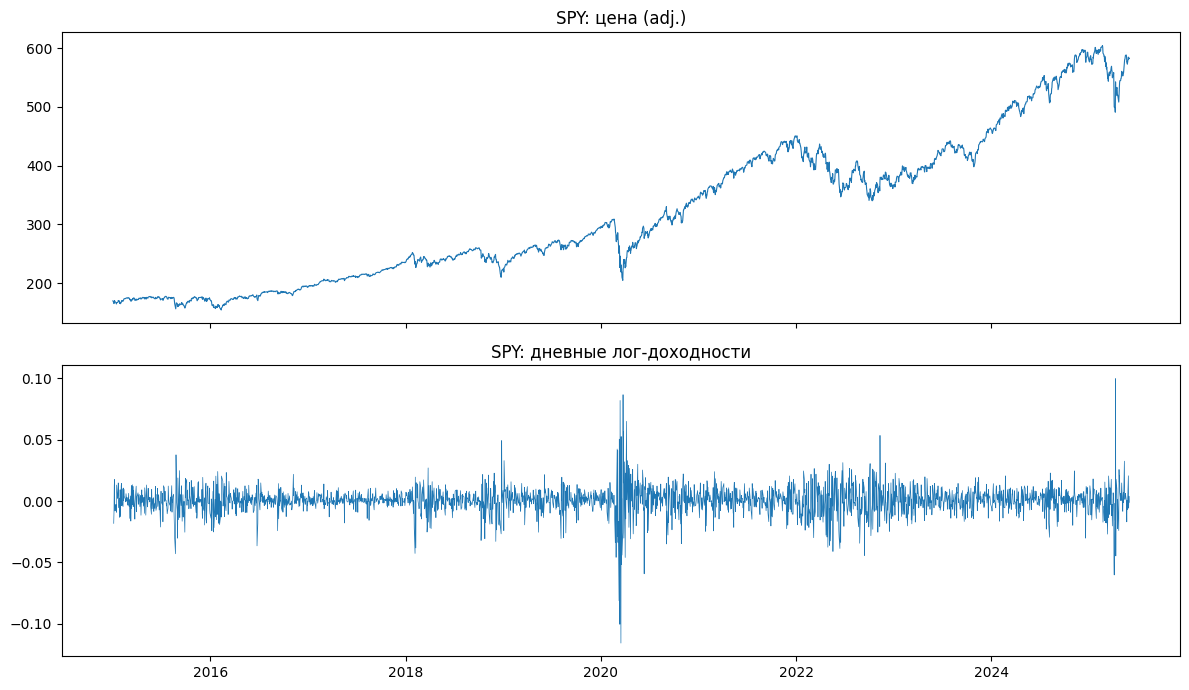

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(prices.index, prices["SPY"], lw=0.8)
axes[0].set_title("SPY: цена (adj.)")
axes[1].plot(r.index, r, lw=0.5)
axes[1].set_title("SPY: дневные лог-доходности")
fig.tight_layout()

## Моменты распределения

In [3]:
desc = pd.Series(
    {
        "mean (дн.)": r.mean(),
        "std (дн.)": r.std(),
        "std (годовая, ×√252)": r.std() * np.sqrt(252),
        "skew": stats.skew(r),
        "excess kurtosis": stats.kurtosis(r),  # 0 у нормального
        "min": r.min(),
        "max": r.max(),
        "min в сигмах": r.min() / r.std(),
    }
)
print(desc.round(4))

mean (дн.)               0.0005
std (дн.)                0.0114
std (годовая, ×√252)     0.1815
skew                    -0.5709
excess kurtosis         14.2267
min                     -0.1159
max                      0.0999
min в сигмах           -10.1357
dtype: float64


Эксцесс на порядок выше нормального (0), худший день — больше 10σ:
по нормальному распределению такое событие «не должно случиться ни разу
за время жизни Вселенной». Это и есть жирные хвосты.

Student-t MLE: ν = 2.65 (малое ν = жирные хвосты)


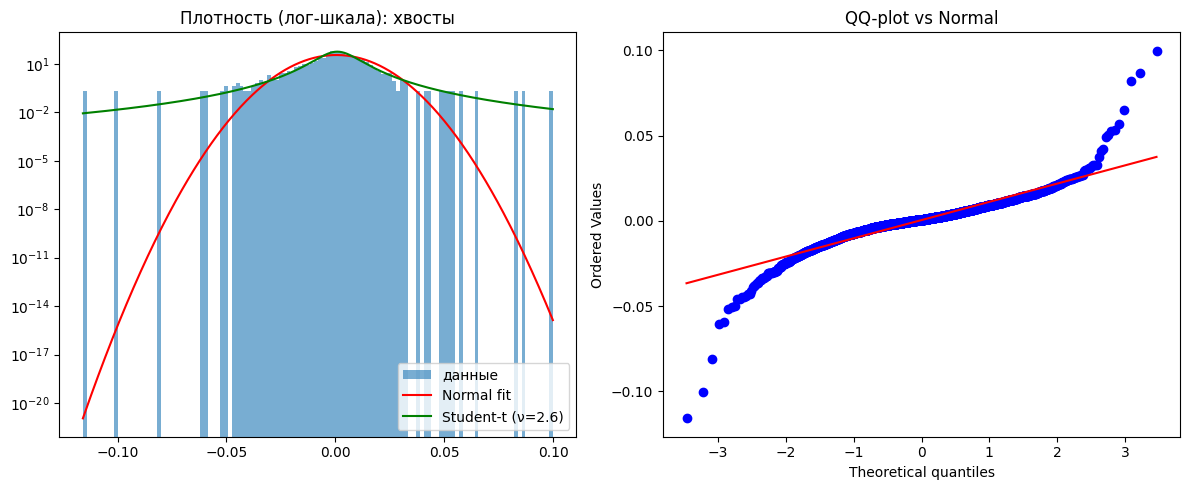

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
x = np.linspace(r.min(), r.max(), 400)
axes[0].hist(r, bins=120, density=True, alpha=0.6, label="данные")
axes[0].plot(x, stats.norm.pdf(x, r.mean(), r.std()), "r-", lw=1.5, label="Normal fit")
nu, loc, scale = stats.t.fit(r)
axes[0].plot(x, stats.t.pdf(x, nu, loc, scale), "g-", lw=1.5, label=f"Student-t (ν={nu:.1f})")
axes[0].set_yscale("log")
axes[0].set_title("Плотность (лог-шкала): хвосты")
axes[0].legend()
stats.probplot(r, dist="norm", plot=axes[1])
axes[1].set_title("QQ-plot vs Normal")
fig.tight_layout()
print(f"Student-t MLE: ν = {nu:.2f} (малое ν = жирные хвосты)")

Student-t с ν≈3 ложится на хвосты заметно лучше нормали — поэтому в
`riskforge.var.parametric` есть вариант `dist="t"`.

## Автокорреляции: r_t почти белый шум, |r_t| — нет

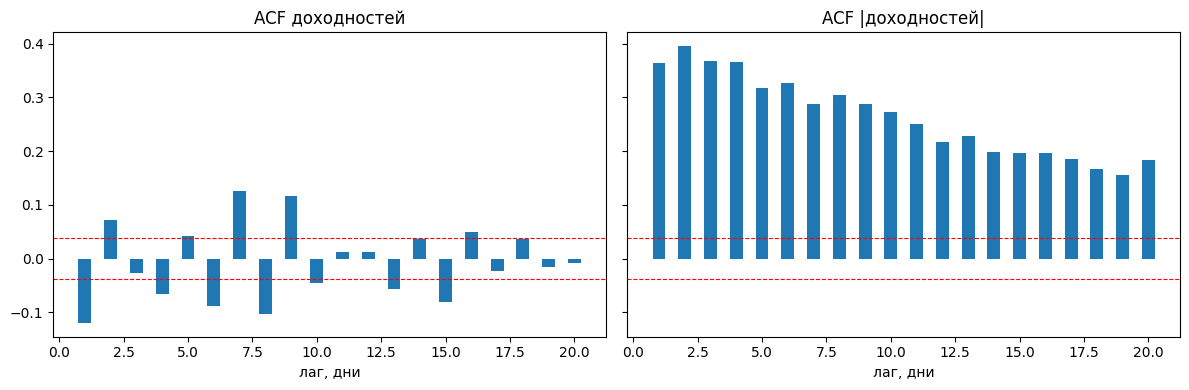

In [5]:
lags = range(1, 21)
acf_r = [r.autocorr(k) for k in lags]
acf_abs = [r.abs().autocorr(k) for k in lags]
ci = 1.96 / np.sqrt(len(r))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, acf, title in [(axes[0], acf_r, "ACF доходностей"), (axes[1], acf_abs, "ACF |доходностей|")]:
    ax.bar(lags, acf, width=0.5)
    ax.axhline(ci, color="r", ls="--", lw=0.8)
    ax.axhline(-ci, color="r", ls="--", lw=0.8)
    ax.set_title(title)
    ax.set_xlabel("лаг, дни")
fig.tight_layout()

## Выводы

1. **Жирные хвосты** (эксцесс ≫ 0, события 10σ) ⇒ нормальный VaR будет занижать
   хвостовой риск; нужны Student-t / исторический метод (ноутбук 02).
2. **|r| автокоррелированы на десятки лагов** при почти нулевой ACF самих r ⇒
   дисперсия предсказуема, сами доходности — нет ⇒ модели условной
   волатильности EWMA/GARCH осмысленны (ноутбук 03).
3. Отрицательный skew — падения резче роста.